# Basic statistics of genome files

In [ ]:
import numpy as np
import os
import gzip
import matplotlib.pyplot as plt

In [2]:
DATDIR = "../data/dataset_entero"

OUTDIR = "../out/nb_genome_sizes"
IMGDIR = f"{OUTDIR}"

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(IMGDIR, exist_ok=True)

In [3]:
##############################################################################
##  Genome sizes

GENOME_LENGTH = 4.6 * 1E6

genome_lengths_fpath = f"{DATDIR}/genome_sizes/genome_lengths.npy"
contig_lengths_fpath = f"{DATDIR}/genome_sizes/contig_lengths.npy.gz"

genome_lengths = np.load(genome_lengths_fpath)
contig_lengths = np.load(
    gzip.GzipFile(contig_lengths_fpath, "r"), allow_pickle=True
)

NGENOMES = len(genome_lengths)

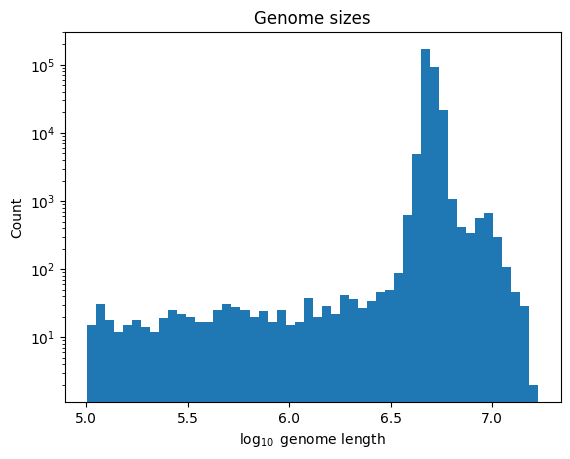

In [4]:
fig, ax = plt.subplots(1, 1)

genome_lengths = [np.sum(x) for x in contig_lengths]
ax.hist(np.log10(genome_lengths), bins=50, log=True)

ax.set_title("Genome sizes")
ax.set_xlabel("$\\log_{10}$ genome length");
ax.set_ylabel("Count");

plt.savefig(f"{IMGDIR}/genome_sizes.pdf")

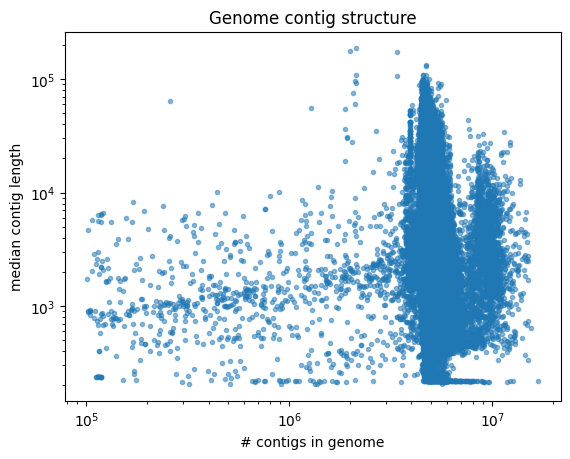

In [5]:
fig, ax = plt.subplots(1, 1, figsize=None)

ax.loglog(
    genome_lengths, 
    [np.median(x) for x in contig_lengths], 
    '.',
    alpha=0.5
)

ax.set_title("Genome contig structure")
ax.set_xlabel("# contigs in genome")
ax.set_ylabel("median contig length");
plt.savefig(f"{IMGDIR}/genome_contig_structure.pdf")